# Chronos 2 Inference Pipeline
Use this file to test out different feature sets with Chronos-2.
Official documentation: https://github.com/amazon-science/chronos-forecasting

Run the following:
```
pip install 'chronos-forecasting>=2.0' 'pandas[pyarrow]' 'matplotlib' 'scikit-learn' 'numpy'
```


In [1]:
# Core
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Chronos - 2
from chronos import Chronos2Pipeline

/Users/cyrilheiniger/git/BFH/SAI1/stonksai/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup & Datenladen  
Diese Zelle importiert alle benötigten Libraries, definiert grundlegende Einstellungen und lädt das UBS-Dataset.  
Die Zeitstempelspalte (`timestamp`) wird geparst und die Zielvariable sowie die Serien-ID werden gesetzt.


In [ ]:
# %% [markdown]
# ================================================================
# 1. SETUP & DATENLADEN
# - Importiert Libraries
# - Lädt UBS-Dataset (data_UBS.csv)
# - Definiert Zeit- & Targetspalte
# ================================================================

# %%
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

CSV_PATH = "data_UBS.csv"  # ggf. anpassen

DATE_COL   = "timestamp"
TARGET_COL = "ctc_vol"      # alternativ: "parkinson_vol"
ID_COL     = "series_id"

df_raw = pd.read_csv(CSV_PATH, parse_dates=[DATE_COL])
df_raw = df_raw.sort_values(DATE_COL).reset_index(drop=True)
df_raw[ID_COL] = "UBS"

print(df_raw.shape)
df_raw.head()


(2694, 120)


,timestamp,ctc_vol,parkinson_vol,ctc_vol_shifted,parkinson_vol_shifted,open,high,low,close,volume,SMA,EMA,RSI,ATR,Real Lower Band,Real Middle Band,Real Upper Band,return,log_return,abs_log_return,range_t,body,upper_wick,lower_wick,body_ratio,upper_wick_ratio,lower_wick_ratio,bb_width,bb_width_norm,day_of_week,range_mean_6,range_std_6,range_mean_24,range_std_24,open_lag1,open_lag2,open_lag3,high_lag1,high_lag2,high_lag3,low_lag1,low_lag2,low_lag3,close_lag1,close_lag2,close_lag3,log_return_lag1,log_return_lag2,log_return_lag3,ret_vol_3,ret_vol_6,ret_vol_12,ret_vol_24,ret_vol_72,rv_6,abs_log_return_lag1,abs_log_return_lag2,abs_log_return_lag3,ret_vol_3_lag1,ret_vol_3_lag2,ret_vol_3_lag3,ret_vol_6_lag1,ret_vol_6_lag2,ret_vol_6_lag3,ret_vol_12_lag1,ret_vol_12_lag2,ret_vol_12_lag3,ret_vol_24_lag1,ret_vol_24_lag2,ret_vol_24_lag3,ret_vol_72_lag1,ret_vol_72_lag2,ret_vol_72_lag3,rv_6_lag1,rv_6_lag2,rv_6_lag3,range_t_lag1,range_t_lag2,range_t_lag3,body_ratio_lag1,body_ratio_lag2,body_ratio_lag3,vol_SMA_6,vol_SMA_24,rel_volume,rel_volume_lag1,rel_volume_lag2,rel_volume_lag3,SMA_lag1,SMA_lag2,SMA_lag3,EMA_lag1,EMA_lag2,EMA_lag3,RSI_lag1,RSI_lag2,RSI_lag3,ATR_lag1,ATR_lag2,ATR_lag3,bb_width_norm_lag1,bb_width_norm_lag2,bb_width_norm_lag3,FEDERAL_FUNDS_RATE,INFLATION,REAL_GDP,REAL_GDP_PER_CAPITA,TREASURY_YIELD,CPI,FTSE_100,SP500,EUROSTOXX_50,VIX,CHFUSD,EURUSD,US1Y,US2Y,US5Y,US10Y,series_id
0,2015-03-13,0.011052,0.006423,0.012903,0.006241,17.41,17.6200,17.35,17.60,1311742,12.2220,12.2425,56.7064,0.1841,12.0628,12.2439,12.4249,0.013825,0.013730,0.013730,0.015442,0.19,0.0200,0.06,0.703704,0.074074,0.222222,0.3621,0.029574,4,0.011084,0.003827,0.011725,0.004733,17.30,17.19,17.32,17.37,17.28,17.375,17.24,17.13,17.215,17.36,17.18,17.26,0.010423,-0.004646,-0.012666,0.009795,0.009959,0.007142,0.011852,0.032377,0.000496,0.010423,0.004646,0.012666,0.011722,0.005019,0.005695,0.007428,0.006413,0.006495,0.006208,0.005270,0.006690,0.011544,0.011321,0.011722,0.046773,0.046760,0.046775,0.000313,0.000259,0.000238,0.007512,0.008718,0.009251,0.461538,0.066667,0.375000,1.695426e+06,1.541502e+06,0.850951,0.669146,0.773717,1.271431,12.2197,12.2501,12.2864,12.1955,12.1970,12.2498,51.0481,46.1463,48.1355,0.1837,0.1875,0.1939,0.036058,0.056490,0.059970,0.11,0.118627,4562.381,58121.0,2.10,236.119,6761.100098,2065.949951,3641.320068,15.42,1.0034,1.0615,0.24,0.67,1.59,2.10,UBS
1,2015-03-16,0.012903,0.006241,0.011185,0.006014,17.90,17.9800,17.86,17.91,1542476,12.2653,12.3383,62.7033,0.1900,12.0532,12.2692,12.4851,0.017614,0.017460,0.017460,0.006696,0.01,0.0700,0.04,0.083333,0.583333,0.333333,0.4319,0.035202,0,0.009460,0.003096,0.011474,0.004837,17.41,17.30,17.19,17.62,17.37,17.280,17.35,17.24,17.130,17.60,17.36,17.18,0.013730,0.010423,-0.004646,0.003521,0.012026,0.008583,0.012329,0.012505,0.000796,0.013730,0.010423,0.004646,0.009795,0.011722,0.005019,0.009959,0.007428,0.006413,0.007142,0.006208,0.005270,0.011852,0.011544,0.011321,0.032377,0.046773,0.046760,0.000496,0.000313,0.000259,0.015442,0.007512,0.008718,0.703704,0.461538,0.066667,1.467554e+06,1.575728e+06,0.978897,0.850951,0.669146,0.773717,12.2220,12.2197,12.2501,12.2425,12.1955,12.1970,56.7064,51.0481,46.1463,0.1841,0.1837,0.1875,0.029574,0.036058,0.056490,0.11,0.118627,4562.381,58121.0,2.13,236.119,6740.600098,2053.399902,3656.209961,16.00,1.0047,1.0524,0.24,0.68,1.60,2.13,UBS
2,2015-03-17,0.011185,0.006014,0.012623,0.006051,17.72,17.8300,17.66,17.78,1415377,12.3004,12.3807,59.0117,0.1890,12.0498,12.2832,12.5166,-0.007259,-0.007285,0.007285,0.009580,0.06,0.0500,0.06,0.352941,0.294118,0.352941,0.4668,0.038003,1,0.009533,0.003092,0.010978,0.004352,17.90,17.41,17.30,17.98,17.62,17.370,17.86,17.35,17.240,17.91,17.60,17.36,0.017460,0.013730,0.010423,0.013341,0.012560,0.009006,0.011268,0.012520,0.000837,0.017460,0.013730,0.010423,0.003521,0.009795,0.011722,0.012026,0.009959,0.007428,0.008583,0.007142,0.006208,0.012329,0.011852,0.011544,0.012505,0.032377,0.046773,0.000796,0.000496,0.000313,0.006696,0.015442,0.007512,0

## 2. Chronos-Modell laden  
In dieser Zelle wird die Chronos-Pipeline initialisiert.  
Wichtig: Die Variable `pipeline` muss am Ende existieren und `predict_df()` unterstützen.  
Dies ist die einzige Stelle, die du je nach Modell anpassen musst.


In [ ]:
# %% [markdown]
# ================================================================
# 2. CHRONOS-MODELL LADEN (KLEINERE VARIANTE)
# - Initialisiert eine leichtere Chronos-Pipeline (z.B. *tiny* Modell)
# - Reduziert Rechenlast pro Vorhersage deutlich
# ================================================================

# %%
from chronos import ChronosPipeline  # <- an dein Package anpassen, falls anders

# Beispiel: wenn du zuvor z.B. ein "small" oder "base"-Modell genutzt hast,
# nimm hier eine *tiny* Variante des gleichen Modells.
# Pseudobeispiel – REPO-NAME an deine Umgebung anpassen:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",   # <- hier: kleinere Modellvariante wählen
    device_map="auto"
)

print("Chronos-Pipeline geladen (tiny Modell).")


Pipeline ist bereits definiert.


## 3. Feature Engineering (Leakage-frei)  
Diese Funktion erzeugt die Trainingsmatrix:
- Lags (lag1, lag2, lag5, usw.)
- optionale Rolling-Features (Mean, Std)
- entfernt alle Zukunftsfeatures und Shift-Spalten  
Sie bildet die Grundlage für alle Modellvarianten im Grid-Search.


In [41]:
# %% [markdown]
# ================================================================
# 3. FEATURE ENGINEERING PIPELINE
# - Erstellt leakage-freie Trainingsmatrix
# - Baut Lags und optionale Rolling-Features
# ================================================================

# %%
def build_training_matrix(
    df: pd.DataFrame,
    target_col: str,
    lag_list,
    rolling_windows=None,
    features_to_use="all",
    date_col: str = DATE_COL,
    id_col: str = ID_COL,
):
    """
    Baut eine leakage-freie Trainingsmatrix.

    - df: Raw DataFrame (mit timestamp, target, Features)
    - target_col: Name der Zielvariable
    - lag_list: Liste der Lags, z.B. [1,2,5,10]
    - rolling_windows: Liste von Rolling-Window-Größen, z.B. [3,7] oder None
    - features_to_use:
        "all"  -> alle Rohfeatures (ohne timestamp/target/id/*shift*)
        Liste  -> nur Features, deren Name einen dieser Strings enthält (Substrings)

    Rückgabe:
    - df_model: fertige Trainingsmatrix
    - feature_cols: Liste der Feature-Spaltennamen
    """

    df = df.sort_values(date_col).reset_index(drop=True).copy()

    # Kandidaten-Features: alles außer Datum, Target, ID, bereits geshiftete Spalten
    all_raw = [
        c for c in df.columns
        if c not in [date_col, target_col, id_col] and "shift" not in c
    ]

    if features_to_use == "all":
        raw_features = all_raw
    else:
        # features_to_use ist z.B. ["open", "high", "low", "close"]
        raw_features = [
            c for c in all_raw
            if any(key in c for key in features_to_use)
        ]

    # Basis-Matrix: ID, Zeit, Target
    df_model = df[[id_col, date_col, target_col]].copy()

    # Lags für alle Features + Target selbst (Vergangenheit vom Target ist erlaubt)
    for col in raw_features + [target_col]:
        for lag in lag_list:
            df_model[f"{col}_lag{lag}"] = df[col].shift(lag)

    # Optional: Rolling-Features (auf Basis der Vergangenheit)
    if rolling_windows:
        for col in raw_features:
            for window in rolling_windows:
                # Rolling nur auf Vergangenheit (shift(1)), um Leakage zu vermeiden
                df_model[f"{col}_rmean{window}"] = (
                    df[col].shift(1).rolling(window).mean()
                )
                df_model[f"{col}_rstd{window}"] = (
                    df[col].shift(1).rolling(window).std()
                )

    # NaN-Vorlauf durch Lags/Rollings entfernen
    max_lag = max(lag_list)
    df_model = df_model.iloc[max_lag:].reset_index(drop=True)

    # Feature-Liste
    feature_cols = [
        c for c in df_model.columns
        if c not in [id_col, date_col, target_col]
    ]

    return df_model, feature_cols


## 4. Rolling Backtest Engine  
Implementiert einen 1-Schritt-Rolling-Forecast:
- trainiert mit allen Daten bis t−1  
- sagt t vorher  
- wiederholt dies für jeden Punkt im Testfenster  
Für Chronos wird eine synthetische Frequenz erzeugt, um Frequenz-Fehler zu vermeiden.


In [42]:
# %% [markdown]
# ================================================================
# 4. ROLLING BACKTEST ENGINE (mit synthetischer Zeitachse & max_steps)
# - Simuliert echte 1-Schritt-Vorhersagen
# - Nutzt künstliche "chronos_time" für Chronos (regelmässige Frequenz)
# - Optional: begrenzt die Anzahl Steps (max_steps), z.B. nur letzte 200 Tage
# ================================================================

# %%
def rolling_backtest(
    df_model: pd.DataFrame,
    feature_cols,
    target_col: str = TARGET_COL,
    id_col: str = ID_COL,
    date_col: str = DATE_COL,
    train_ratio: float = 0.8,
    max_steps: int | None = None,
):
    """
    Rolling 1-Schritt-Vorhersage mit optionaler Begrenzung der Step-Anzahl.

    - max_steps=None  -> kompletter Testhorizont
    - max_steps=N     -> nur die letzten N Punkte des Testhorizonts werden genutzt
    """

    # Sortieren & Kopie
    df_model = df_model.sort_values(date_col).reset_index(drop=True).copy()

    # Synthetische, reguläre Zeitachse für Chronos
    df_model["chronos_time"] = pd.date_range(
        start="2000-01-01",
        periods=len(df_model),
        freq="D"
    )

    # Train/Test-Split
    split_idx = int(len(df_model) * train_ratio)
    future_full = df_model.iloc[split_idx:].copy()
    df_roll     = df_model.copy()

    # Original-Horizont
    horizon_full = len(future_full)

    # Falls max_steps gesetzt ist -> nur letzten N Punkte des Testhorizonts verwenden
    if max_steps is not None and max_steps < horizon_full:
        future_df = future_full.iloc[-max_steps:].copy()
        # start_index = split_idx + (horizon_full - max_steps)
        start_index_offset = horizon_full - max_steps
    else:
        future_df = future_full.copy()
        start_index_offset = 0

    rolling_preds = []
    horizon = len(future_df)

    for local_step in range(horizon):
        # globaler Step-Index im ursprünglichen Testhorizont
        global_step = start_index_offset + local_step

        end_idx = split_idx + global_step
        context_step = df_roll.iloc[:end_idx].copy()

        df_in = context_step[[id_col, "chronos_time", target_col] + feature_cols].reset_index(drop=True)

        pred = pipeline.predict_df(
            df_in,
            prediction_length=1,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column=id_col,
            timestamp_column="chronos_time",
            target=target_col,
        )

        # Echten Timestamp zuordnen
        true_ts = future_df.iloc[local_step][date_col]
        pred[date_col] = true_ts

        if "chronos_time" in pred.columns:
            pred = pred.drop(columns=["chronos_time"])

        rolling_preds.append(pred)

        # Logging: relativer Fortschritt auf reduzierten Horizon
        if (local_step + 1) % 25 == 0 or local_step == horizon - 1:
            print(f"Rolling Step {local_step + 1}/{horizon} (global {global_step + 1}/{horizon_full})")

    pred_df = pd.concat(rolling_preds, ignore_index=True)

    # Join mit echten Werten
    result = pred_df.merge(
        future_df[[id_col, date_col, target_col]],
        on=[id_col, date_col],
        how="left",
    )

    return result


## 5. Modellgüte (Metriken)  
Diese Funktionen berechnen:
- RMSE (Root Mean Squared Error)  
- MAE  (Mean Absolute Error)  
- R²   (Erklärte Varianz)  
- Quantile-Loss (Pinball Loss für 0.1 / 0.5 / 0.9)  
Damit wird jedes Modell im Grid objektiv bewertet.


In [43]:
# %% [markdown]
# ================================================================
# 5. MESSUNG DER MODELLGÜTE
# - RMSE, MAE, R², Quantile-Loss (0.1/0.5/0.9)
# ================================================================

# %%
def pinball_loss(y_true: pd.Series, y_pred: pd.Series, q: float) -> float:
    diff = y_true - y_pred
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

def evaluate_results(res: pd.DataFrame, target_col: str = TARGET_COL):
    y_true = res[target_col].astype(float)
    y_p50  = res["0.5"].astype(float)
    y_p10  = res["0.1"].astype(float)
    y_p90  = res["0.9"].astype(float)

    rmse = np.sqrt(np.mean((y_true - y_p50) ** 2))
    mae  = np.mean(np.abs(y_true - y_p50))

    ss_res = np.sum((y_true - y_p50) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    q10 = pinball_loss(y_true, y_p10, 0.1)
    q50 = pinball_loss(y_true, y_p50, 0.5)
    q90 = pinball_loss(y_true, y_p90, 0.9)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2":  r2,
        "Q10": q10,
        "Q50": q50,
        "Q90": q90,
    }


## 6. Grid Definition für Modellvarianten  
Hier definierst du die Varianten, die getestet werden:
- unterschiedliche Lag-Listen  
- unterschiedliche Rolling-Fenster  
- verschiedene Feature-Sets (All / Preis / Makro)  
Das Grid wird später vollautomatisch durchlaufen.


In [44]:
# %% [markdown]
# ================================================================
# 6. MINI-GRID DEFINITION (REDUZIERTE FEATURES)
# - 4 Modellvarianten:
#     • 1 Lag-Set (kurze Historie)
#     • 2 Rolling-Sets (ohne vs. mit Rolling)
#     • 2 Feature-Sets (1 vs. 2 Features)
# - Deutlich weniger Features → schnelleres Training
# ================================================================

# %%
# Eine Lag-Variante (kurze Historie)
lag_settings = [
    [1, 2, 5],
]

# Rolling-Varianten: ohne und mit mittleren Fenstern
rolling_settings = [
    None,       # ohne Rolling-Features
    [5, 10],    # einfache Glättung (5er & 10er Fenster)
]

# Feature-Sets:
# - nur Schlusskurs ("close")
# - Schlusskurs + Volumen
feature_settings = [
    ["close"],                      # 1 Feature
    ["close", "volume"],            # 2 Features
]

print("Lag-Settings:", lag_settings)
print("Rolling-Settings:", rolling_settings)
print("Feature-Settings:", feature_settings)


Lag-Settings: [[1, 2, 5]]
Rolling-Settings: [None, [5, 10]]
Feature-Settings: [['close'], ['close', 'volume']]


## 7. Grid-Run: Training & Evaluation aller Modellvarianten  
Diese Zelle führt den vollständigen Benchmark aus:  
Für jede Kombination aus Lags, Features und Rolling-Fenstern wird:  
1. eine Trainingsmatrix gebaut  
2. ein Rolling-Backtest ausgeführt  
3. die Performance gemessen  
Alle Resultate werden in `results_df` gespeichert.


In [45]:
# %% [markdown]
# ================================================================
# 7. GRID RUN – MINI-GRID (4 Modelle)
# - Baut pro Kombination eine Trainingsmatrix
# - Führt Rolling-Backtest durch
# - Berechnet Metriken & sammelt alles in results_df
# ================================================================

# %%
import time

results_table = []
model_id = 0

start_time = time.time()

for lags in lag_settings:
    for roll in rolling_settings:
        for feat in feature_settings:

            model_id += 1
            print("=" * 80)
            print(f"Modell {model_id}: lags={lags}, rolling={roll}, features={feat}")
            print("=" * 80)

            # 1) Trainingsmatrix
            df_mat, feat_cols = build_training_matrix(
                df=df_raw,
                target_col=TARGET_COL,
                lag_list=lags,
                rolling_windows=roll,
                features_to_use=feat,
                date_col=DATE_COL,
                id_col=ID_COL,
            )

            print("Trainingsmatrix Shape:", df_mat.shape)
            print("Anzahl Features:", len(feat_cols))

            # Falls nach Lags/Rollings nichts übrig bleibt (theoretisch):
            if df_mat.shape[0] < 30:
                print("⚠️ Zu wenig Daten nach Feature-Engineering – Modell wird übersprungen.")
                continue

            # 2) Rolling-Backtest
            res = rolling_backtest(
                df_model=df_mat,
                feature_cols=feat_cols,
                target_col=TARGET_COL,
                id_col=ID_COL,
                date_col=DATE_COL,
                train_ratio=0.8,
                max_steps=200,
            )

            # 3) Metriken
            metrics = evaluate_results(res, target_col=TARGET_COL)

            # 4) Ergebnisse sammeln
            results_table.append({
                "model_id": model_id,
                "lags": lags,
                "rolling": roll,
                "features": feat,
                "n_rows": len(df_mat),
                "n_features": len(feat_cols),
                **metrics,
            })

end_time = time.time()
print(f"Grid-Lauf abgeschlossen. Dauer: {end_time - start_time:.1f} Sekunden")

results_df = pd.DataFrame(results_table)
results_df


Modell 1: lags=[1, 2, 5], rolling=None, features=['close']
Trainingsmatrix Shape: (2689, 18)
Anzahl Features: 15
Rolling Step 25/200 (global 363/538)
Rolling Step 50/200 (global 388/538)
Rolling Step 75/200 (global 413/538)
Rolling Step 100/200 (global 438/538)
Rolling Step 125/200 (global 463/538)
Rolling Step 150/200 (global 488/538)
Rolling Step 175/200 (global 513/538)
Rolling Step 200/200 (global 538/538)
Modell 2: lags=[1, 2, 5], rolling=None, features=['close', 'volume']
Trainingsmatrix Shape: (2689, 33)
Anzahl Features: 30
Rolling Step 25/200 (global 363/538)
Rolling Step 50/200 (global 388/538)
Rolling Step 75/200 (global 413/538)
Rolling Step 100/200 (global 438/538)
Rolling Step 125/200 (global 463/538)
Rolling Step 150/200 (global 488/538)
Rolling Step 175/200 (global 513/538)
Rolling Step 200/200 (global 538/538)
Modell 3: lags=[1, 2, 5], rolling=[5, 10], features=['close']
Trainingsmatrix Shape: (2689, 34)
Anzahl Features: 31
Rolling Step 25/200 (global 363/538)
Rolling S

,model_id,lags,rolling,features,n_rows,n_features,RMSE,MAE,R2,Q10,Q50,Q90
0,1,"[1, 2, 5]",None,[close],2689,15,0.004886,0.003242,0.705402,0.000679,0.001621,0.000995
1,2,"[1, 2, 5]",None,"[close, volume]",2689,30,0.004724,0.003240,0.724625,0.000702,0.001620,0.000927
2,3,"[1, 2, 5]","[5, 10]",[close],2689,31,0.004576,0.003172,0.741678,0.000657,0.001586,0.000950
3,4,"[1, 2, 5]","[5, 10]","[close, volume]",2689,66,0.004710,0.003245,0.726299,0.000711,0.001622,0.000938


## 8. Modellranking & Feature-Set-Analyse  
Diese Zelle:
- berechnet einen Composite-Score pro Modell  
- sortiert alle Modelle nach Gesamtperformance  
- vergleicht Feature-Sets gegeneinander  
- zeigt die Top-Modelle jeder Feature-Kategorie  
Dies ist die zentrale Bewertung des gesamten Experiments.


In [46]:
# %% [markdown]
# ================================================================
# 8. MODELLRANKING & FEATURE-SET-VERGLEICH
# ================================================================

# %%
results_df["score"] = (
    -results_df["RMSE"]*0.6
    -results_df["MAE"]*0.2
    +results_df["R2"]*0.2
)

results_df["features_str"] = results_df["features"].astype(str)

results_df_sorted = results_df.sort_values("score", ascending=False)
display(results_df_sorted.head(10))

feature_set_stats = (
    results_df
    .groupby("features_str")
    .agg(
        models=("model_id","count"),
        mean_rmse=("RMSE","mean"),
        mean_mae=("MAE","mean"),
        mean_r2=("R2","mean"),
        mean_score=("score","mean")
    )
    .sort_values("mean_score", ascending=False)
)

display(feature_set_stats)

top_per_set = (
    results_df_sorted
    .groupby("features_str")
    .head(3)
    .reset_index(drop=True)
)

display(top_per_set)


,model_id,lags,rolling,features,n_rows,n_features,RMSE,MAE,R2,Q10,Q50,Q90,score,features_str
2,3,"[1, 2, 5]","[5, 10]",[close],2689,31,0.004576,0.003172,0.741678,0.000657,0.001586,0.000950,0.144956,['close']
3,4,"[1, 2, 5]","[5, 10]","[close, volume]",2689,66,0.004710,0.003245,0.726299,0.000711,0.001622,0.000938,0.141785,"['close', 'volume']"
1,2,"[1, 2, 5]",None,"[close, volume]",2689,30,0.004724,0.003240,0.724625,0.000702,0.001620,0.000927,0.141442,"['close', 'volume']"
0,1,"[1, 2, 5]",None,[close],2689,15,0.004886,0.003242,0.705402,0.000679,0.001621,0.000995,0.137500,['close']


,models,mean_rmse,mean_mae,mean_r2,mean_score
features_str,,,,,
"['close', 'volume']",2,0.004717,0.003242,0.725462,0.141614
['close'],2,0.004731,0.003207,0.723540,0.141228


,model_id,lags,rolling,features,n_rows,n_features,RMSE,MAE,R2,Q10,Q50,Q90,score,features_str
0,3,"[1, 2, 5]","[5, 10]",[close],2689,31,0.004576,0.003172,0.741678,0.000657,0.001586,0.000950,0.144956,['close']
1,4,"[1, 2, 5]","[5, 10]","[close, volume]",2689,66,0.004710,0.003245,0.726299,0.000711,0.001622,0.000938,0.141785,"['close', 'volume']"
2,2,"[1, 2, 5]",None,"[close, volume]",2689,30,0.004724,0.003240,0.724625,0.000702,0.001620,0.000927,0.141442,"['close', 'volume']"
3,1,"[1, 2, 5]",None,[close],2689,15,0.004886,0.003242,0.705402,0.000679,0.001621,0.000995,0.137500,['close']


## 9. Visualisierung des besten Modells  
Hier wird das beste Modell aus dem Ranking erneut berechnet und seine Vorhersage visualisiert:  
- True vs. Predicted (Median)  
- 10%–90% Vorhersageintervall  
Perfekt für die qualitative Analyse und für Abbildungen in der Masterarbeit.


Rolling Step 25/200 (global 363/538)
Rolling Step 50/200 (global 388/538)
Rolling Step 75/200 (global 413/538)
Rolling Step 100/200 (global 438/538)
Rolling Step 125/200 (global 463/538)
Rolling Step 150/200 (global 488/538)
Rolling Step 175/200 (global 513/538)
Rolling Step 200/200 (global 538/538)


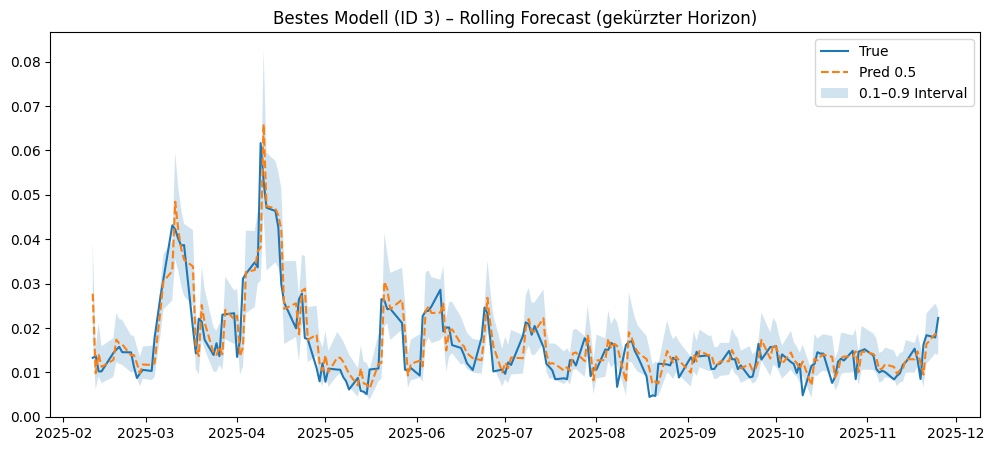

In [51]:
# %% [markdown]
# ================================================================
# 9. BESTES MODELL – erneut bauen & plotten (mit begrenztem Horizon)
# ================================================================

# %%
best = results_df_sorted.iloc[0]

df_best, feats_best = build_training_matrix(
    df_raw,
    TARGET_COL,
    best["lags"],
    best["rolling"],
    best["features"]
)

# hier: nur z.B. die letzten 200 Test-Punkte nehmen
res_best = rolling_backtest(
    df_model=df_best,
    feature_cols=feats_best,
    target_col=TARGET_COL,
    id_col=ID_COL,
    date_col=DATE_COL,
    train_ratio=0.8,
    max_steps=200,     # <- anpassen, falls du weniger/mehr willst
)

# %%
res_best_sorted = res_best.sort_values(DATE_COL)

plt.figure(figsize=(12,5))
plt.plot(res_best_sorted[DATE_COL], res_best_sorted[TARGET_COL], label="True")
plt.plot(res_best_sorted[DATE_COL], res_best_sorted["0.5"], label="Pred 0.5", linestyle="--")
plt.fill_between(
    res_best_sorted[DATE_COL],
    res_best_sorted["0.1"],
    res_best_sorted["0.9"],
    alpha=0.2,
    label="0.1–0.9 Interval"
)

plt.legend()
plt.title(f"Bestes Modell (ID {best['model_id']}) – Rolling Forecast (gekürzter Horizon)")
plt.show()
